#   26 September 2025 -> 6 February 2026
###  Elisha Gabriel B. Agoot
###  Applied Physics 155 Long Exam 1 -- Part II

**Academic Integrity Statement**

As a student of the University of the Philippines, I pledge to act ethically and uphold the value of honor and excellence.

I understand that expected misconduct on given assignments/examinations will be reported to appropriate offices and if established, will result in disciplinary action in accordance with University rules, policies, and procedures.

*(sgd.)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Problem #1 (Problem 4.17 in Problem Set)

Use **LU decomposition** (without and with pivoting) for:
~~~
    A = np.array([4., 4, 8, 4, 4, 5, 3, 7, 8, \
    3, 9, 9, 4, 7, 9, 5]).reshape(4,4)
    bs = np.array([1., 2, 3, 4])
~~~
- [X] Does pivoting help in any way? 
- [X] What are your conclusions about this matrix?

You sometimes hear the advice that, since the problem arises from one of
the $U_{ii}$’s being zero, you should replace it with a small number, say $10^{−20}$.
- [X] Does this work? Explain.

In [ ]:
A = np.array([4.,4,8,4, \
              4,5,3,7, \
              8,3,9,9, \
              4,7,9,5]).reshape(4,4)
bs = np.array([1.,2,3,4])
'''
    where due to the declaration of their respective first elements,
    all other elements are of the type float64.
'''

'\n    where due to the declaration of their respective first elements,\n    all other elements are of the type float64.\n'

Note that the augmented matrix $\bm{A}|\bm{b}$ is of the form 

$ \bm{A}|\bm{b} = \left(
\begin{matrix}
    4 & 4 & 8 & 4 \\
    4 & 5 & 3 & 7 \\
    8 & 3 & 9 & 9 \\
    4 & 7 & 9 & 5 \\
\end{matrix} \ \right|\left.
\begin{matrix}
    1 \\ 2 \\ 3 \\ 4
\end{matrix} \right) $

Using elementary row operations, we try to decompose it without pivoting first.

\begin{align*}
    \bm{A}|\bm{b} = &\left(
\begin{matrix}
    4 & 4 & 8 & 4 \\
    4 & 5 & 3 & 7 \\
    8 & 3 & 9 & 9 \\
    4 & 7 & 9 & 5 \\
\end{matrix} \ \right|\left.
\begin{matrix}
    1 \\ 2 \\ 3 \\ 4
\end{matrix} \right) \\

\begin{split}
    R_2^\prime &= R_2 - R_1 \\
    R_3^\prime &= R_3 - 2R_1 \\
    R_4^\prime &= R_4 - R_1 \\
\end{split}
 \rightarrow &\left(
\begin{matrix}
    4 & 4 & 8 & 4 \\
    0 & 1 & -5 & 3 \\
    0 & -5 & -7 & 1 \\
    0 & 3 & 1 & 1 \\
\end{matrix} \ \right|\left.
\begin{matrix}
    1 \\ 1 \\ 1 \\ 3
\end{matrix} \right) \\

\begin{split}
    R_3^\prime &= R_3 + 5R_2 \\
    R_4^\prime &= R_4 - 3R_2 \\
\end{split}
 \rightarrow &\left(
\begin{matrix}
    4 & 4 & 8 & 4 \\
    0 & 1 & 5 & 3 \\
    0 & 0 & -31 & 16 \\
    0 & 0 & 16 & 8 \\
\end{matrix} \ \right|\left.
\begin{matrix}
    1 \\ 1 \\ 6 \\ 0
\end{matrix} \right) \\

\begin{split}
    R_4^\prime &= R_4 - \frac{1}{2}R_3 \\
\end{split}
 \rightarrow &\left(
\begin{matrix}
    4 & 4 & 8 & 4 \\
    0 & 1 & 5 & 3 \\
    0 & 0 & -31 & 16 \\
    0 & 0 & 0 & 0 \\
\end{matrix} \ \right|\left.
\begin{matrix}
    1 \\ 1 \\ 6 \\ 3
\end{matrix} \right) \\
\end{align*}

Now, there is a line of thoughts/concepts in Math 40 (Linear Algebra) that connects some properties of matrices to their "solvability," so to speak. Notably, this set of statements is equivalent:
1. A matrix $\bm{A}$ is nonsingular if and only if there exists an inverse $\bm{A}^{-1}$.
1. The linear equation $\bm{Ax} = \bm{b}$ has a unique solution $\bm{x} = \bm{A}^{-1}\bm{b}$ for any $\bm{b}$.
1. $\bm{Ax} = \bm{0}$ has the trivial solution $\bm{x} = \bm{0}_{n}$, where $\bm{0}$ is the null vector of length $n$.
1. $\text{RREF}(\bm{A}) = \bm{I}_n$, where $\bm{I}$ is the identity matrix of dimension $n$.
1. The matrix $\bm{A}$ is a product of elementary matrices.
1. The matrix's determinant exists, such that it is nonzero.

The fourth statement refers to what is known as the Reduced Row Echelon Form of a matrix, which is derived if we continue applying row operations such that the resulting matrix has its pivot points (in our case, $A_{ii}$) **as the only nonzero value in its column.**

Due to the presence of the last row being completely 0 in our decomposition of $\bm{A}$, then its RREF can never become an identity matrix (contains one at all elements of the principal diagonal). It then follows that our given matrix $A$, however square:
- (from 1) is a singular matrix, therefore its inverse does not exist;
- (from 2) does not have a unique solution for any vector $\bm{b}$: either infinite solutions or no solution at all; and
- (from 6) has a determinant $\text{det}(A) = 0$.

Furthermore, the nature of last row reveals that this is an *inconsistent* system, since the equivalent equation would imply that as the coefficients of all elements of $\bm{x}$ are 0, their sum would somehow produce a non-zero number.

> ***ANSWER:***
>
> So specifically, the linear equation $\bm{Ax} = \bm{b}$ with our given $\bm{A}$ will have no solution at all for any given $\bm{b}$ of compatible dimension. Pivoting would not help in any way due to the existence of a dependent (and inconsistent) row.

However, this does not yet count out if the matrix itself is $\bm{LU}$-decomposable or not. We can extend our notion by considering the nature of the matrix reduction: even in the latest result of our row operations, we see that we have reduced our matrix into an upper triangular matrix. Linear algebra posits that all previous row operations are *actually* matrices themselves that have been "factored out" to the left of our augmented matrix. It is then a good guess that if all of those row operation matrices are multiplied together, then they should form a lower triangular matrix.

In [ ]:
x = sp.linalg.solve(A, bs)

/opt/anaconda3/envs/pisika/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=6.56289e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
np_det_A = np.linalg.det(A)
sp_det_A = sp.linalg.det(A)

print(f'NumPy det(A) = {np_det_A}') 
print(f'SciPy det(A) = {sp_det_A}') 
print(f'xs = {x}') 
A @ x == bs

NumPy det(A) = 0.0
SciPy det(A) = 0.0
xs = [-4.50359963e+15 -1.50119988e+15  1.50119988e+15  3.00239975e+15]


array([False, False, False, False])

The $\bm{x}$ matrix containing entirely large numbers is uncharacteristic of our given $\bm{A}$ and $\bm{b}$, thus it can be attributed to floating-point errors. The `linalg` package itself tells that our matrix is ill-conditioned. Obviously, plugging this resultant $\bm{x}$ into our linear equation will not produce our $\bm{b}$ by orders of magnitude. 

Although with it, the evaluation of the determinant is in agreement with Statement 6, and even colludes with my guess of our matrix to still be LU-decomposable.

According to the [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.det.html) of the determinant function `det()`, it is computed by performing an LU factorization of the input, using the `getrf` routine of the LAPACK (Linear Algebra Package). A resulting determinant that's consistent with theory and an implicit success on LU factorization of $\bm{A}$ only leads to assume that an LU factorization does indeed exist for our $\bm{A}$.

In [ ]:
p, l, u = sp.linalg.lu(A)

print(f'P = \n {p}')
print(f'L = \n {l}')
print(f'U = \n {u} \n')

P = 
 [[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]
L = 
 [[ 1.          0.          0.          0.        ]
 [ 0.5         1.          0.          0.        ]
 [ 0.5         0.63636364  1.          0.        ]
 [ 0.5         0.45454545 -0.33333333  1.        ]]
U = 
 [[ 8.          3.          9.          9.        ]
 [ 0.          5.5         4.5         0.5       ]
 [ 0.          0.         -4.36363636  2.18181818]
 [ 0.          0.          0.          0.        ]] 



And here it is, above, in discrete form. The fourth row, in any permutation, should be dependent (all 0).

If we do follow the advice to make the fourth diagonal number to a *really* small number close to zero, here's what happens.

In [ ]:
u[-1, -1] = 1E-20
A_new = p @ l @ u

x_new = sp.linalg.solve(A_new, bs)
delta = A_new - A
print(f' x_new = \n {x_new} \n\n A_new - A = \n{delta}')

 x_new = 
 [ 3.37769972e+15  1.12589991e+15 -1.12589991e+15 -2.25179981e+15] 

 A_new - A = 
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 8.8817842e-16]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]


/opt/anaconda3/envs/pisika/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=8.75053e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
#   I use the word sensitivity below because 
#   the degree of change that we do introduce *does*
#   change the resultant x vector into something more sensible.

#   Suppose we increase the size of our change to
u[-1, -1] = 1E-10
#   The x-vector's components actually drops fast in value.
#       It should follow that if we set the above value to the 
#       same magnitude as the other components of A, then we
#       would probably reach a solution BUT keeping in mind that
#       it is not the same matrix A anymore.       

A_new = p @ l @ u

x_new = sp.linalg.solve(A_new, bs)
delta = A_new - A
print(f' x_new = \n {x_new} \n\n A_new - A = \n{delta}')

 x_new = 
 [ 2.99997311e+10  9.99991036e+09 -9.99991036e+09 -1.99998207e+10] 

 A_new - A = 
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000896e-10]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]


The resultant $\bm{x}$ vector is still composed of uncharacteristically large numbers. The most sound conclusion that we can derive from this is that we are seeing seeing some *sensitivity* of the original matrix to small changes of value, but none of that will lead to any solution because it ***is*** ill-conditioned in the first place due to underlying mathematics.

Alternatively, here's another solution if we assume from the start that $\bm{A}$ is indeed LU decomposable.

In [ ]:
lu, piv = sp.linalg.lu_factor(A)
x_alt = sp.linalg.lu_solve((lu, piv), bs)

lu, piv, x_alt

/opt/anaconda3/envs/pisika/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Diagonal number 4 is exactly zero. Singular matrix.
  return f(*arrays, *other_args, **kwargs)


(array([[ 8.        ,  3.        ,  9.        ,  9.        ],
        [ 0.5       ,  5.5       ,  4.5       ,  0.5       ],
        [ 0.5       ,  0.63636364, -4.36363636,  2.18181818],
        [ 0.5       ,  0.45454545, -0.33333333,  0.        ]]),
 array([2, 3, 3, 3], dtype=int32),
 array([ nan,  inf, -inf, -inf]))

In [ ]:
print(f'Is x     a valid solution? {np.allclose(A @ x - bs, np.zeros((4,)))}')
print(f'Is x_new a valid solution? {np.allclose(A @ x_new - bs, np.zeros((4,)))}')
print(f'Is x_alt a valid solution? No as well, seeing that it\'s not even comprised of numbers.')

Is x     a valid solution? False
Is x_new a valid solution? False
Is x_alt a valid solution? No as well, seeing that it's not even comprised of numbers.


## Problem #2.

This problem deals with our analytical expectations for the total error,
$$\epsilon = \epsilon_{app} + \epsilon_{ro}$$

in the forward difference

$$\epsilon = \frac{h}{2}\bigg| f^{\prime\prime}(x_i) \bigg| + \frac{2}{h}\bigg|f(x_i) \bigg|\epsilon_m$$

vs. that of the central difference method 

$$\epsilon = \frac{h^2}{6}\bigg| f^{\prime\prime\prime}(x_i) \bigg| + \frac{1}{h}\bigg|f(x_i) \bigg|\epsilon_m$$

where $\epsilon_m \approx 2.2\times 10^{-16}$ is the usual machine precision for `double` variables.

Let $h$ take on the values $10^{-1}$, $10^{-2}$, $10^{-3}$, $10^{-4}$
and plot the total error for the two cases.

Assume evaluation of the error at a value of $x$, say $x_i$ where $f(x_i)=1$, $f^{\prime\prime}(x_i)=0.1$, and $f^{\prime\prime\prime}(x_i)=100$. 

- [X] Do you understand these results? 
- [X] Is there anything odd with this setup? 
- [X] Provide one possible form of the function.


In [65]:
#   Initialization
N = 4
h = [10**-(i+1) for i in range(N)]
eps_m = 2.2E-16

#   Forward Difference Error
def forw_diff_err(h, f, f_pp):
    ''' INPUTS
        h       matrix of various step sizes
        f       value of f(x_i)     used in e_approx
        f_pp    value of f''(x_i)   used in e_round    
    '''
    e_approx = 0.5*h * f_pp
    e_round = (2/h) * f*eps_m
    return e_approx, e_round

#   Central Difference Error
def cent_diff_err(h, f, f_ppp):
    ''' INPUTS
        h       matrix of various step sizes
        f       value of f(x_i)     used in e_approx
        f_pp    value of f''(x_i)   used in e_round    
    '''
    e_approx = (h**2/6) * f_ppp
    e_round = (1/h) * f*eps_m
    return e_approx, e_round

In [94]:
f_val = np.array([1, 0, 0.1, 100])
x_pos = np.linspace(-10, 10, 50)
x_forw_errs = [forw_diff_err(i, f_val[0], f_val[2]) for i in h]
x_cent_errs = [cent_diff_err(i, f_val[0], f_val[3]) for i in h]

x_forw_errs, x_cent_errs

print(f'Forward diff errors of various h')
for i in range(len(h)):
    print(f'h = {h[i]:<7}   e_approx = {x_forw_errs[i][0]:.3E}     e_round = {x_forw_errs[i][1]:.3E}    e_total = {np.sum(x_forw_errs[i]):.3E}')

print(f'\nCentral diff errors of various h')
for i in range(len(h)):
    print(f'h = {h[i]:<7}   e_approx = {x_cent_errs[i][0]:.3E}     e_round = {x_cent_errs[i][1]:.3E}    e_total = {np.sum(x_cent_errs[i]):.3E}')

Forward diff errors of various h
h = 0.1       e_approx = 5.000E-03     e_round = 4.400E-15    e_total = 5.000E-03
h = 0.01      e_approx = 5.000E-04     e_round = 4.400E-14    e_total = 5.000E-04
h = 0.001     e_approx = 5.000E-05     e_round = 4.400E-13    e_total = 5.000E-05
h = 0.0001    e_approx = 5.000E-06     e_round = 4.400E-12    e_total = 5.000E-06

Central diff errors of various h
h = 0.1       e_approx = 1.667E-01     e_round = 2.200E-15    e_total = 1.667E-01
h = 0.01      e_approx = 1.667E-03     e_round = 2.200E-14    e_total = 1.667E-03
h = 0.001     e_approx = 1.667E-05     e_round = 2.200E-13    e_total = 1.667E-05
h = 0.0001    e_approx = 1.667E-07     e_round = 2.200E-12    e_total = 1.667E-07


The above result separately lists the approximation error and the roundoff error for each $h$. The sums are listed beside.

> ***Answer***  
>
> One can observe that the approximation error decreases and rounding error increases in magnitude as step size decreases in magnitude.
> It should be noted that the total error for these values of $h$ mostly arises from the approximation error. 
> That should not be the case, as the proper choice of $h$ would have the total error minimized.
> Then, one can infer that the contribution of both error terms should be roughly on the same magnitude, and not like the sampled $\epsilon$ values above.

Analytically, we show this by assuming that our total error is a function of $h$, taking its derivative with respect to $h$ and equating it to $0$; 
or we can just do it numerically and generate the error values for smaller values of $h$ like I did below.


In [99]:
N = 10
h = [10**-(i+1) for i in range(N)]

f_val = np.array([1, 0, 0.1, 100])
x_pos = np.linspace(-10, 10, 50)
x_forw_errs = [forw_diff_err(i, f_val[0], f_val[2]) for i in h]
x_cent_errs = [cent_diff_err(i, f_val[0], f_val[3]) for i in h]

print(f'Forward diff errors of various h')
for i in range(len(h)):
    print(f'h = {h[i]:<7}   e_approx = {x_forw_errs[i][0]:.3E}     e_round = {x_forw_errs[i][1]:.3E}    e_total = {np.sum(x_forw_errs[i]):.3E}')

print(f'\nCentral diff errors of various h')
for i in range(len(h)):
    print(f'h = {h[i]:<7}   e_approx = {x_cent_errs[i][0]:.3E}     e_round = {x_cent_errs[i][1]:.3E}    e_total = {np.sum(x_cent_errs[i]):.3E}')

Forward diff errors of various h
h = 0.1       e_approx = 5.000E-03     e_round = 4.400E-15    e_total = 5.000E-03
h = 0.01      e_approx = 5.000E-04     e_round = 4.400E-14    e_total = 5.000E-04
h = 0.001     e_approx = 5.000E-05     e_round = 4.400E-13    e_total = 5.000E-05
h = 0.0001    e_approx = 5.000E-06     e_round = 4.400E-12    e_total = 5.000E-06
h = 1e-05     e_approx = 5.000E-07     e_round = 4.400E-11    e_total = 5.000E-07
h = 1e-06     e_approx = 5.000E-08     e_round = 4.400E-10    e_total = 5.044E-08
h = 1e-07     e_approx = 5.000E-09     e_round = 4.400E-09    e_total = 9.400E-09
h = 1e-08     e_approx = 5.000E-10     e_round = 4.400E-08    e_total = 4.450E-08
h = 1e-09     e_approx = 5.000E-11     e_round = 4.400E-07    e_total = 4.400E-07
h = 1e-10     e_approx = 5.000E-12     e_round = 4.400E-06    e_total = 4.400E-06

Central diff errors of various h
h = 0.1       e_approx = 1.667E-01     e_round = 2.200E-15    e_total = 1.667E-01
h = 0.01      e_approx = 1.667E

Here, we see that the total error indeed gets smaller beyond the values of $h$ given with the problem.
The smallest error for both diff. formulas see that the magnitudes of both error terms are indeed close in magnitude.

A possible form of the function can be acquired by integrating from the third derivative of the function, $f^{\prime\prime\prime}(x)$.

\begin{align*}
    \int f^{\prime\prime\prime}(x) \ dx &= f^{\prime\prime}(x) \\
    \int 100 \ dx &= 100x + C \\
    \\
    f^{\prime\prime}(x) &= 100x + C
\end{align*}

When $f^{\prime\prime}(x_i) = 0.1$,

\begin{align*}
    \quad 0.1 = 100x_i + C \quad &\rightarrow \quad C = 0.1 - 100x_i \\
    \\
    \int f^{\prime\prime}(x) \ dx &= f^{\prime}(x) \\
    \int (100x+C) \ dx &= \frac{100}{2} x^2 + Cx + D \\
    \\
    f^{\prime}(x) &= 50 x^2 + Cx + D \\
\end{align*}

Since it was not specified, let $f^{\prime}(x_i) = E \in \mathbb{R}$,     

\begin{align*}
    \quad E = 50 x_i^2 + Cx + D \quad &\rightarrow \quad 
        \begin{align*} 
            D &= -50x_i^2 - Cx_i + E \\ 
            &= -50x_i^2 - (0.1 - 100x_i)x_i + E \\
            &= -50x_i^2 - 0.1x_i + 100x_i^2 + E \\
            D &= 50x_i^2 - 0.1x_i - E 
            \end{align*} 
    \\ \\
    \int f^{\prime}(x) \ dx &= f(x) \\
    \int 50x^2 + Cx + D \ dx &= \frac{50}{3} x^3 + \frac{C}{2} x^2 + Dx + F \\
    f(x) &= \frac{50}{3} x^3 + \frac{C}{2} x^2 + Dx + F \\
\end{align*}

When $f(x_i) = 1$

\begin{align*}
    1 &= \frac{50}{3} x_i^3 + \frac{C}{2} x_i^2 + Dx_i + F \\
    F   &= 1 - \frac{50}{3} x_i^3 - \frac{C}{2} x_i^2 - Dx_i \\
        &= 1 - \frac{50}{3} x_i^3 - \frac{0.1 - 100x_i}{2} x_i^2 - (50x_i^2 - 0.1x_i - E )x_i \\
        &= 1 - \frac{50}{3} x_i^3 - 0.05x_i^2 + 50x_i^3 - 50x_i^3 + 0.1x_i^2 + Ex_i \\
    F   &= 1 - \frac{50}{3} x_i^3 + 0.05x_i^2 + Ex_i \in \mathbb{R} \\
\end{align*}

Therefore, the possible equation is of the form

\begin{align*}
    f(x) &= \frac{50}{3} x^3 + \frac{0.1 - 100x_i}{2} x^2 + (50x_i^2 - 0.1x_i - E)x + (1 - \frac{50}{3} x_i^3 + 0.05x_i^2 + Ex_i) \\
    f(x) &= \frac{50}{3} x^3 + (0.05 - 50x_i) x^2 + (50x_i^2 - 0.1x_i - E)x + (1 - \frac{50}{3} x_i^3 + 0.05x_i^2 + Ex_i) \\
\end{align*}

## Problem #3.

We now examine a case where plotting a function on the computer can
seriously mislead us. The function we wish to plot is:

$$f(x) = x^6 + 0.1 \log\left(\big| 1+3(1-x) \big|\right)$$


- [X] Use 100 points from x = 0.5 to 1.5 to plot this
function in matplotlib. 

Do you see a dip? Consider the function itself and
reason about what you should be seeing. Then, use a much finer grid and ensure that you capture the analytically expected behavior. 

- [X] Discuss how you should then go about picking the grid granularity.

### Analysis.

Note that an infinite discontinuity of $\log(x)$ exists at $x=0.$ For our function $f(x)$, this is located at

\begin{align*}
|1+3(1-x)| = 0 \quad \rightarrow \quad 1+3(1-x) &= 0 \\
1-x &= - \frac{1}{3} \\
x &= 1+ \frac{1}{3} \\
x &\approx 1.33
\end{align*}

where we indeed see it in a [graph from Desmos](https://www.desmos.com/calculator/lfiqd28rwn) below, which is displayed as a dip.

![A picture of a graph of f(x) in Desmos.](./desmos-graph.png)

However, the above graph is still not correct. Seeing as $\log(x)$ itself has no value at the discontinuity, it follows that there is no value of $f(x)$ at its discontinuity at $x=1.\overline{33}$ - there is an asymptote.

We conject that from the trend of $\log(x) \to -\infty$ as $x\to0$, the second term of $f(x)$ also makes the function approach $-\infty$ whether we approach $x=1.\overline{33}$ from the left or right.

This further implies that as our data points `x` approach $\sim$`1.333...`, we expect a massive decrease in the `y` output values, which we will only see if we increase the resolution of our `x` interval; either by increasing the overall granularity 

Finally, we implement what is asked of the problem into code:

In [76]:
def func(x):
    return x**6 + 0.1*np.log(np.abs(1+3*(1-x)))

#   Initialization
N = 100
x_pos = np.linspace(0.5, 1.5, N)
y_pos = [func(i) for i in x_pos]

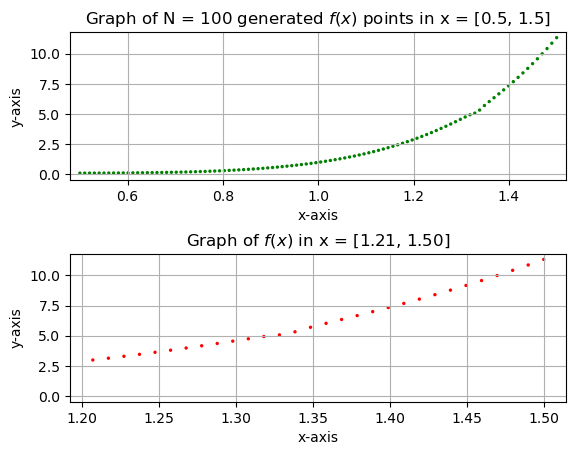

In [77]:
fig, (ax, ax2) = plt.subplots(2, 1, sharey=True)
ax.scatter(x_pos, y_pos, marker='o', s=2, ls="", color='green')
ax2_start = 70
ax2.scatter(x_pos[ax2_start:], y_pos[ax2_start:], marker='o', s=2, ls="", color='red')

#   Customization of the first plot
ax.grid()
x_pad = x_pos[1] - x_pos[0]
y_pad = y_pos[-1] - y_pos[-2]
ax.set_xlim(x_pos[0]-2*x_pad, x_pos[-1]+2*x_pad) 
ax.set_ylim(0-y_pad, np.max(y_pos)+y_pad)
ax.set_xlabel(f'x-axis') 
ax.set_ylabel(f'y-axis') 
#ax.set_xticks([] ,minor=True) 
#ax.set_xticklabels(labels) 
ax.set_title(f'Graph of N = {N} generated $f(x)$ points in x = [{x_pos[0]}, {x_pos[-1]}]')

#   Customization of the second plot
ax2.grid()
ax2.set_xlabel(f'x-axis') 
ax2.set_ylabel(f'y-axis') 
ax2.set_title(f'Graph of $f(x)$ in x = [{x_pos[ax2_start]:.2f}, {1.5:.2f}]')

#   Last adjustments and display
#ax.tick_params(which='major', width=0.3)
plt.subplots_adjust(hspace=0.5)
plt.show()

We can then observe that there is a noticeable discontinuity at around $x \approx 1.33$ indeed. It's most noticeable in the second figure wherein adjacent data points **only appear** to be smoothly linear: the slope of data points to the left of `1.33` is different to the slope of points to its right.

In [78]:
#   Finer grid
N = np.int32(1E7)
x_pos_fine = np.linspace(0.5, 1.5, N)
y_pos_fine = [func(i) for i in x_pos_fine]

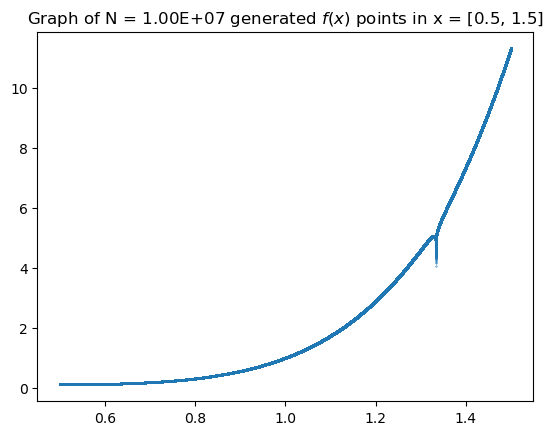

In [83]:
fig2, axs = plt.subplots()
axs.scatter(x_pos_fine, y_pos_fine, s=0.05)
ax2.grid()
ax2.set_xlabel(f'x-axis') 
ax2.set_ylabel(f'y-axis') 
plt.title(f'Graph of N = {N:.2E} generated $f(x)$ points in x = [{x_pos[0]}, {x_pos[-1]}]')
plt.show()

Within the same interval, the dip already appears albeit not pronounced and well-sampled.
A more reasonable resolution to reflect the accurate behavior of our function is to increase `N` to `1E6` or `1E7`, but we computational efficiency diminishes (`N = 1E7` generated for 30s and plotted for 30s more on my end) if we increase it further.

> 
> 
>In choosing the granularity of data points, one should (in practice) be able to get by choosing a resolution that is one (or two) magnitudes lower than the "resolution" of the point of singularity or other errant behavior.
>I put "resolution" in quotes since it may be an arbitrary decision on where to stop considering further decimal places, such as in our case, `1.333...` (repeating).
> 
> 

Alternatively, one might choose to localize granularity by only increasing it in the region near the singularity by basically generating a separate group of points then appending it (and sorting the appended dataset).
However, this choice has consequences on what we can do with the datapoints; as numerical differentiation **requires** constant spacing between points, therefore won't work, and some integration methods such as Gaussian quadrature will adapt fine to the new set of data points. 

#   Scratch

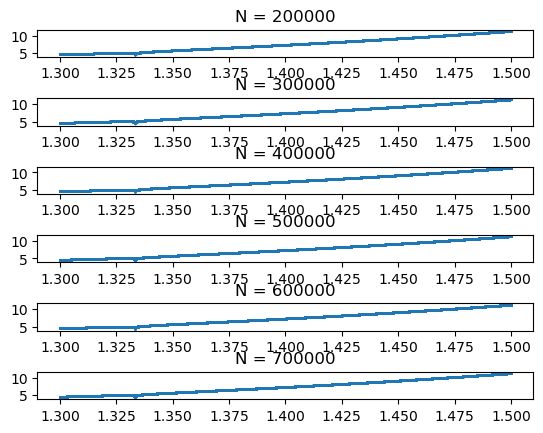

In [19]:
#   Initialization
elem = 6
thresh = 0.80
N_mat = [100_000*(i+2) for i in range(elem)]
X_pos = [np.linspace(0.5, 1.5, i) for i in N_mat]
Y_pos = [func(X_pos[i]) for i in range(len(X_pos))]

fig2, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, sharey=True)
a = [ax1, ax2, ax3, ax4, ax5, ax6]
for i in range(elem):
    a[i].scatter(X_pos[i][np.int32(N_mat[i]*thresh):], Y_pos[i][np.int32(N_mat[i]*thresh):], s=0.15)
    a[i].set_title(f'N = {N_mat[i]}')

plt.subplots_adjust(hspace=1.5)
fig.set_size_inches(200, 200)
plt.show()

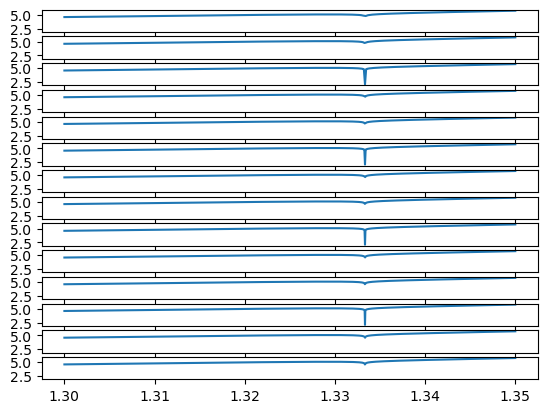

In [20]:
lem = elem+8

new_N_mat = [100*(i+2) for i in range(lem)]
new_x_pos = [np.linspace(1.30, 1.35, i) for i in new_N_mat]
new_y_pos = [func(i) for i in new_x_pos]

fig3, axs = plt.subplots(lem, 1, sharey='all', sharex='all')

for i in range(lem):
    axs[i].plot(new_x_pos[i], new_y_pos[i])